In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.autolayout'] = True

df_tracks = pd.read_csv("data/data.csv", low_memory=False)
df_year = pd.read_csv("data/data_by_year.csv", low_memory=False)
df_genres = pd.read_csv("data/data_by_genres.csv", low_memory=False)

## How music has changed over the last century

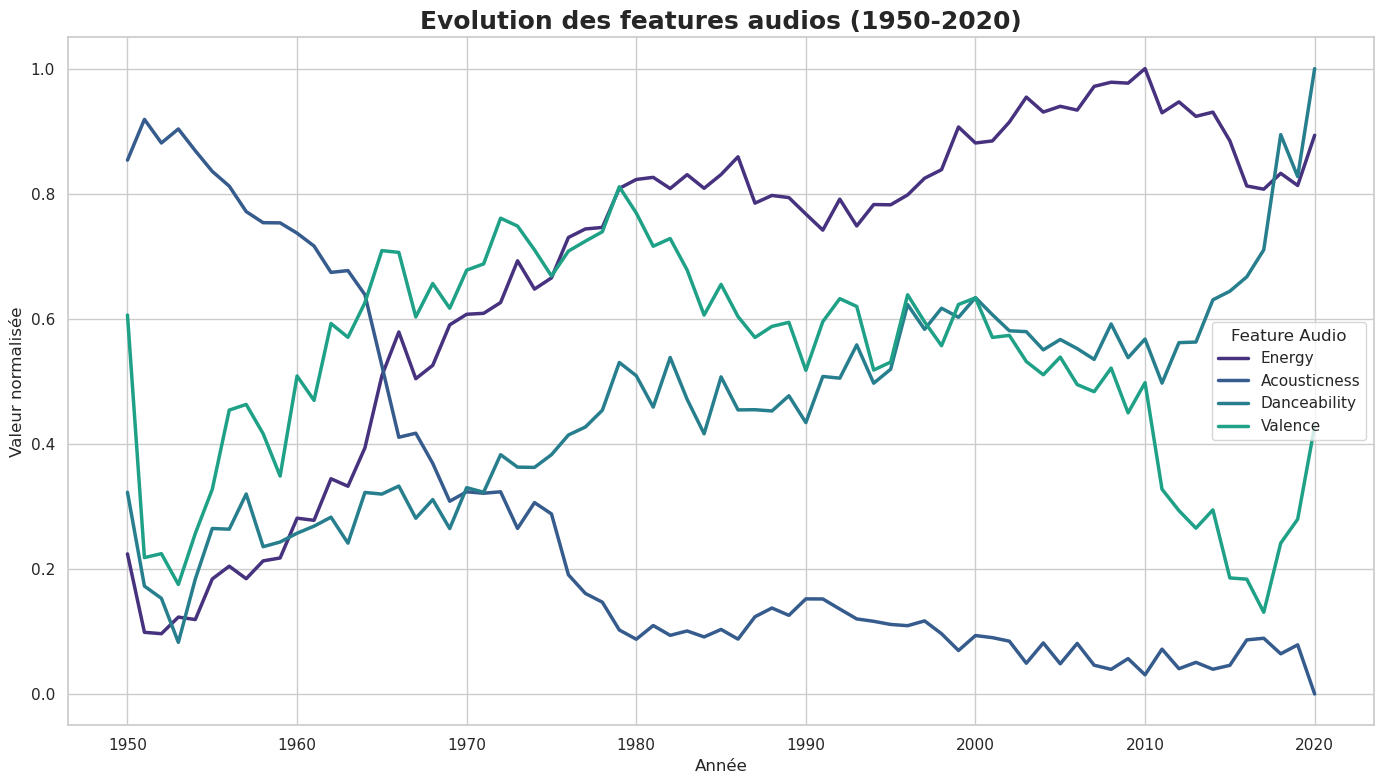

In [6]:
features_to_plot = ['energy', 'acousticness', 'danceability', 'valence']
scaler = MinMaxScaler()
df_year_normalized = df_year.copy()
df_year_normalized[features_to_plot] = scaler.fit_transform(df_year[features_to_plot])

plt.figure(figsize=(14, 8))
for feature in features_to_plot:
    sns.lineplot(
        x='year',
        y=feature,
        data=df_year_normalized[df_year_normalized['year'] >= 1950],
        label=feature.capitalize(),
        linewidth=2.5
    )

plt.title('Evolution des features audios (1950-2020)', fontsize=18, fontweight='bold')
plt.xlabel('Année', fontsize=12)
plt.ylabel('Valeur normalisée', fontsize=12)
plt.legend(title='Feature Audio', fontsize=11)
plt.show()

## Distribution of key audio features across all songs

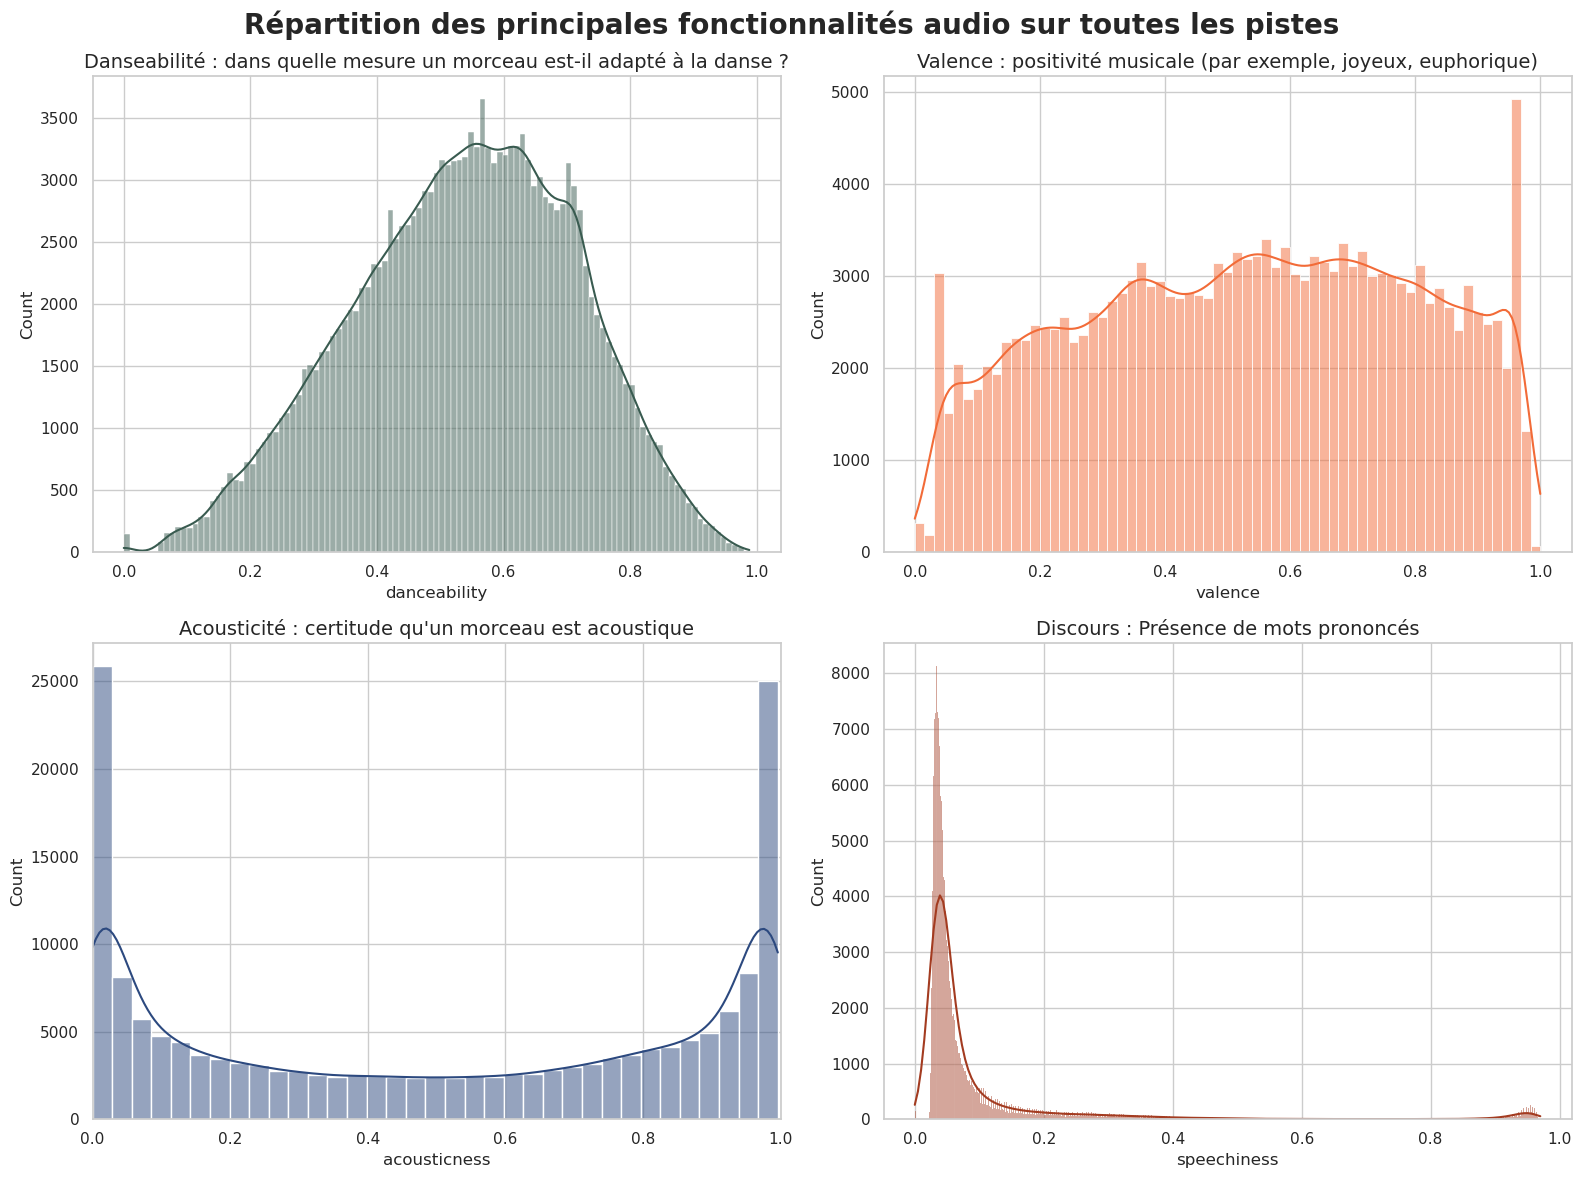

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Répartition des principales fonctionnalités audio sur toutes les pistes', fontsize=20, fontweight='bold')

sns.histplot(df_tracks['danceability'], ax=axes[0, 0], color='#395B50', kde=True)
axes[0, 0].set_title('Danseabilité : dans quelle mesure un morceau est-il adapté à la danse ?', fontsize=14)

sns.histplot(df_tracks['valence'], ax=axes[0, 1], color='#F26B38', kde=True)
axes[0, 1].set_title('Valence : positivité musicale (par exemple, joyeux, euphorique)', fontsize=14)

sns.histplot(df_tracks['acousticness'], ax=axes[1, 0], color='#2C497F', kde=True)
axes[1, 0].set_title("Acousticité : certitude qu'un morceau est acoustique", fontsize=14)
axes[1, 0].set_xlim(0, 1)

sns.histplot(df_tracks['speechiness'], ax=axes[1, 1], color='#A33B20', kde=True)
axes[1, 1].set_title('Discours : Présence de mots prononcés', fontsize=14)

plt.show()

## Heatmap to visualize the correlations between different audio features

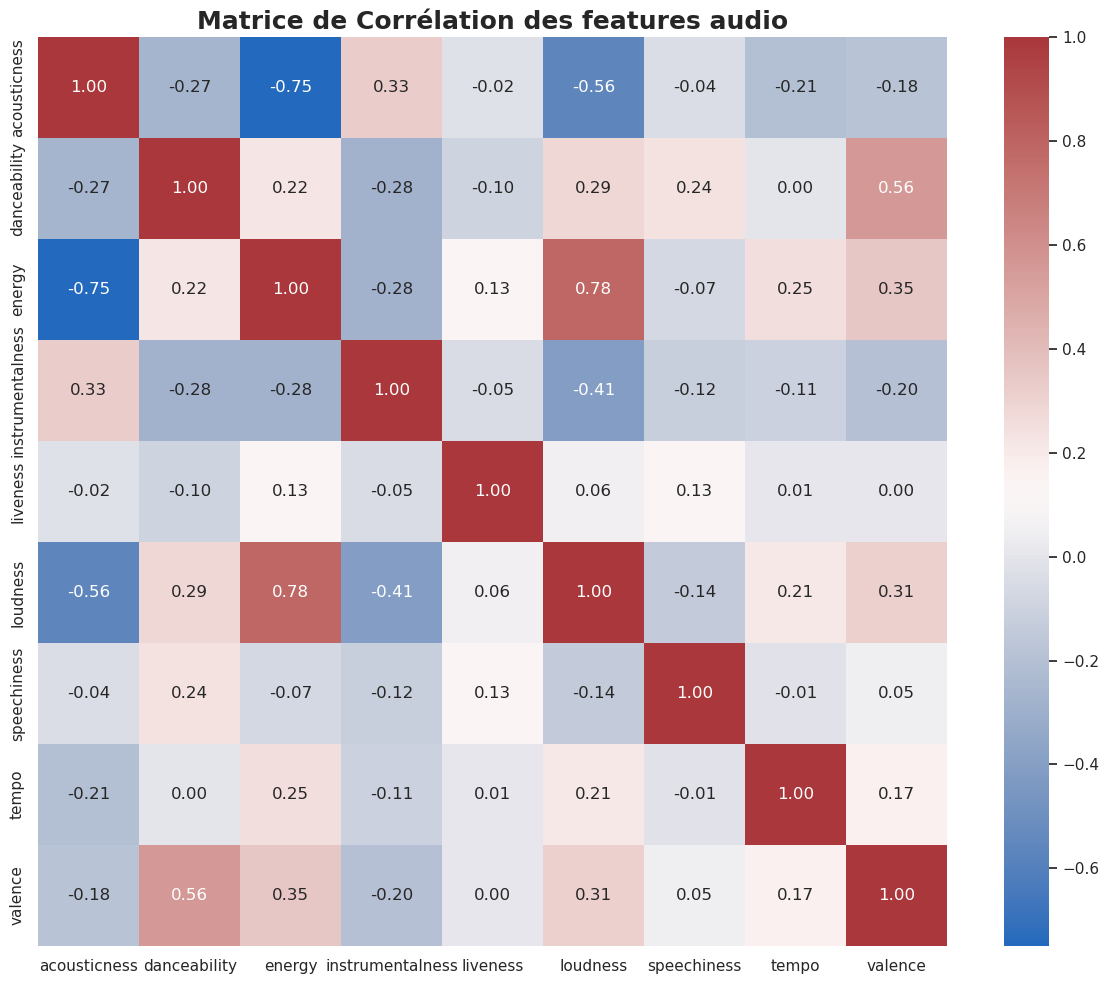

In [14]:
cols = ['acousticness', 'danceability', 'energy', 'instrumentalness',
        'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

for col in cols:
    df_tracks[col] = df_tracks[col].astype(str).str.replace(',', '.')
    df_tracks[col] = pd.to_numeric(df_tracks[col], errors='coerce')

audio_features = df_tracks[cols]

plt.figure(figsize=(12, 10))
sns.heatmap(
    audio_features.corr(),
    annot=True,
    cmap='vlag',
    fmt='.2f'
)
plt.title('Matrice de Corrélation des features audio', fontsize=18, fontweight='bold')
plt.show()

/tmp/ipykernel_91178/2174345815.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='mako', orient='h')


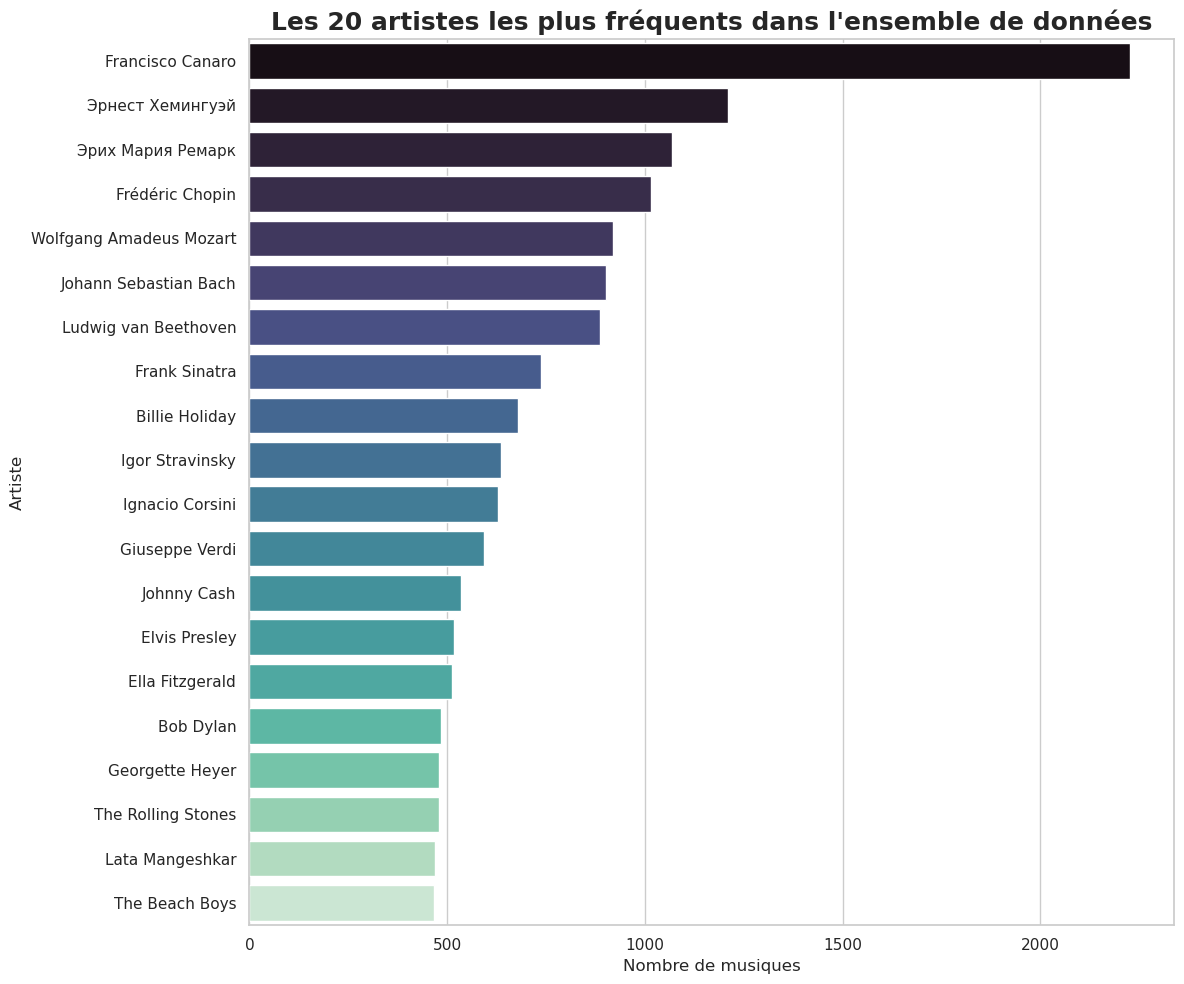

In [13]:
df_tracks['main_artist'] = df_tracks['artists'].str.extract(r"\'(.*?)\'")

plt.figure(figsize=(12, 10))
top_artists = df_tracks['main_artist'].value_counts().head(20)

sns.barplot(x=top_artists.values, y=top_artists.index, palette='mako', orient='h')

plt.title("Les 20 artistes les plus fréquents dans l'ensemble de données", fontsize=18, fontweight='bold')
plt.xlabel('Nombre de musiques', fontsize=12)
plt.ylabel('Artiste', fontsize=12)
plt.show()